In [17]:
import math
import random
import yfinance as yf
import matplotlib.pyplot as plt

In [18]:
# ============================================================
# PROJECT INPUTS
# ============================================================

# Portfolio of 2 different assets
TICKER_1 = "XLE"   # Energy Select Sector SPDR Fund
TICKER_2 = "XLK"   # Technology Select Sector SPDR Fund

# Portfolio value (>= 15 000 EUR)
PORTFOLIO_VALUE_EUR = 18000.0

# Portfolio weights
W1 = 0.35
W2 = 0.65

# One-year period under normal economic conditions
NORMAL_START = "2021-01-01"
NORMAL_END = "2021-12-31"

# One-year stressed period
STRESS_START = "2020-02-01"
STRESS_END = "2020-12-31"

# Risk-free rate used for Black-Scholes
RISK_FREE_RATE = 0.04

# Option parameters for Questions 5 and 7
OPTION_UNDERLYING = TICKER_2
OPTION_MATURITY_YEARS = 1.0 / 12.0   # 1 month
OPTION_STRIKE_STYLE = "ATM"
OPTION_STRIKE_CUSTOM = 100.0

# EWMA / Hybrid lambda
LAMBDA_EWMA = 0.94
LAMBDA_HYBRID = 0.94

# Monte Carlo settings
N_MONTE_CARLO = 20000
RANDOM_SEED = 42

# Confidence levels
ALPHA_VAR_1 = 0.01
ALPHA_VAR_5 = 0.05
ALPHA_VAR_10 = 0.10
ALPHA_ES_5 = 0.05

# One-tailed z-values
Z_VALUES = {
    0.01: -2.33,
    0.05: -1.65,
    0.10: -1.28
}

# Dataset file name
DATASET_FILENAME = "xle_xlk_portfolio_dataset.csv"

random.seed(RANDOM_SEED)

print("Inputs loaded successfully.")

Inputs loaded successfully.


In [19]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def mean_manual(values):
    total = 0.0
    for x in values:
        total += x
    return total / len(values)

def variance_manual_sample(values):
    n = len(values)
    mu = mean_manual(values)
    total = 0.0
    for x in values:
        total += (x - mu) ** 2
    return total / (n - 1)

def std_manual_sample(values):
    return math.sqrt(variance_manual_sample(values))

def covariance_manual_sample(x, y):
    n = len(x)
    mx = mean_manual(x)
    my = mean_manual(y)
    total = 0.0
    for i in range(n):
        total += (x[i] - mx) * (y[i] - my)
    return total / (n - 1)

def correlation_manual(x, y):
    sx = std_manual_sample(x)
    sy = std_manual_sample(y)
    cov_xy = covariance_manual_sample(x, y)
    return cov_xy / (sx * sy)

def sort_ascending(values):
    copied = values[:]
    copied.sort()
    return copied

def percentile_from_sorted(sorted_vals, alpha):
    n = len(sorted_vals)
    k = math.ceil(alpha * n) - 1
    if k < 0:
        k = 0
    if k >= n:
        k = n - 1
    return sorted_vals[k]

def quantile_historical(values, alpha):
    sorted_vals = sort_ascending(values)
    return percentile_from_sorted(sorted_vals, alpha)

def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))

def normal_pdf(x):
    return (1.0 / math.sqrt(2.0 * math.pi)) * math.exp(-0.5 * x * x)

def black_scholes_call_price(S, K, r, sigma, T):
    if T <= 0:
        return max(S - K, 0.0)
    if sigma <= 0:
        return max(S - K * math.exp(-r * T), 0.0)

    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)

    return S * normal_cdf(d1) - K * math.exp(-r * T) * normal_cdf(d2)

def black_scholes_delta_call(S, K, r, sigma, T):
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return normal_cdf(d1)

def black_scholes_gamma_call(S, K, r, sigma, T):
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return normal_pdf(d1) / (S * sigma * math.sqrt(T))

def random_standard_normal_box_muller():
    u1 = random.random()
    u2 = random.random()
    if u1 == 0:
        u1 = 1e-12
    z = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
    return z

def download_adjusted_close(ticker, start_date, end_date):
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    closes = data["Close"].values.flatten().tolist()
    dates = [str(d.date()) for d in data.index]
    return dates, closes

def align_two_series(dates1, prices1, dates2, prices2):
    dict1 = {}
    dict2 = {}

    for i in range(len(dates1)):
        dict1[dates1[i]] = prices1[i]

    for i in range(len(dates2)):
        dict2[dates2[i]] = prices2[i]

    common_dates = []
    for d in dict1:
        if d in dict2:
            common_dates.append(d)

    common_dates.sort()

    p1 = []
    p2 = []
    for d in common_dates:
        p1.append(dict1[d])
        p2.append(dict2[d])

    return common_dates, p1, p2

def simple_returns(prices):
    returns = []
    for i in range(1, len(prices)):
        ret = prices[i] / prices[i - 1] - 1.0
        returns.append(ret)
    return returns

def portfolio_returns_two_assets(r1, r2, w1, w2):
    rp = []
    for i in range(len(r1)):
        rp.append(w1 * r1[i] + w2 * r2[i])
    return rp

def portfolio_expected_return_two_assets(mu1, mu2, w1, w2):
    return w1 * mu1 + w2 * mu2

def portfolio_volatility_two_assets(sigma1, sigma2, rho12, w1, w2):
    variance_p = (
        (w1 ** 2) * (sigma1 ** 2)
        + (w2 ** 2) * (sigma2 ** 2)
        + 2.0 * w1 * w2 * rho12 * sigma1 * sigma2
    )
    return math.sqrt(variance_p)

def var_parametric(mu, sigma, portfolio_value, alpha):
    z = Z_VALUES[alpha]
    return -(mu + z * sigma) * portfolio_value

def ewma_variance_series(returns, lambda_):
    initial_var = variance_manual_sample(returns)
    sigma2 = [initial_var]

    for i in range(1, len(returns)):
        new_var = lambda_ * sigma2[-1] + (1.0 - lambda_) * (returns[i - 1] ** 2)
        sigma2.append(new_var)

    return sigma2

def var_parametric_ewma(returns, portfolio_value, alpha, lambda_):
    mu = mean_manual(returns)
    sigma2_series = ewma_variance_series(returns, lambda_)
    sigma_t = math.sqrt(sigma2_series[-1])
    return -(mu + Z_VALUES[alpha] * sigma_t) * portfolio_value, sigma_t, sigma2_series

def var_historical(returns, portfolio_value, alpha):
    q = quantile_historical(returns, alpha)
    return -q * portfolio_value, q

def es_historical(returns, portfolio_value, alpha):
    q = quantile_historical(returns, alpha)
    tail = []

    for r in returns:
        if r <= q:
            tail.append(r)

    avg_tail = mean_manual(tail)
    return -avg_tail * portfolio_value, q

def es_parametric_normal(mu, sigma, portfolio_value, alpha):
    z = Z_VALUES[alpha]
    phi = normal_pdf(z)
    es = (-mu + sigma * phi / alpha) * portfolio_value
    return es

def hybrid_weights(n, lambda_):
    denom = 1.0 - (lambda_ ** n)
    base = (1.0 - lambda_) / denom

    weights = []
    for i in range(1, n + 1):
        w = base * (lambda_ ** (i - 1))
        weights.append(w)

    return weights

def var_hybrid(returns, portfolio_value, alpha, lambda_):
    n = len(returns)
    weights_recent_to_old = hybrid_weights(n, lambda_)

    pairs = []
    for i in range(n):
        weight = weights_recent_to_old[n - 1 - i]
        pairs.append((returns[i], weight))

    pairs.sort(key=lambda x: x[0])

    cumulative_weight = 0.0
    threshold_return = pairs[0][0]

    for ret, wt in pairs:
        cumulative_weight += wt
        threshold_return = ret
        if cumulative_weight >= alpha:
            break

    var_value = -threshold_return * portfolio_value
    return var_value, threshold_return

def monte_carlo_var_parametric(mu, sigma, portfolio_value, alpha, n_sim):
    simulated_returns = []

    for _ in range(n_sim):
        z = random_standard_normal_box_muller()
        r = mu + sigma * z
        simulated_returns.append(r)

    var_mc, q = var_historical(simulated_returns, portfolio_value, alpha)
    return var_mc, simulated_returns, q

def scale_var_sqrt_time(var_daily, horizon_days):
    return var_daily * math.sqrt(horizon_days)

def simulate_gbm_terminal_prices(S0, mu, sigma, T_years, n_paths):
    prices = []

    for _ in range(n_paths):
        z = random_standard_normal_box_muller()
        ST = S0 * math.exp((mu - 0.5 * sigma * sigma) * T_years + sigma * math.sqrt(T_years) * z)
        prices.append(ST)

    return prices

def taylor_delta_gamma_pnl(delta, gamma, dS):
    return delta * dS + 0.5 * gamma * (dS ** 2)

def var_taylor_delta_gamma(S0, K, r, sigma, T, mu_underlying, n_paths, alpha):
    delta = black_scholes_delta_call(S0, K, r, sigma, T)
    gamma = black_scholes_gamma_call(S0, K, r, sigma, T)

    simulated_prices = simulate_gbm_terminal_prices(S0, mu_underlying, sigma, T, n_paths)
    pnl = []

    for ST in simulated_prices:
        dS = ST - S0
        dC = taylor_delta_gamma_pnl(delta, gamma, dS)
        pnl.append(dC)

    pnl_sorted = sort_ascending(pnl)
    q = percentile_from_sorted(pnl_sorted, alpha)
    var_value = -q

    return var_value, pnl, delta, gamma

def full_repricing_var_historical(price_series_underlying, sigma, r, T, K, alpha):
    S0 = price_series_underlying[-1]
    C0 = black_scholes_call_price(S0, K, r, sigma, T)

    pnl = []

    for i in range(1, len(price_series_underlying)):
        shock_factor = price_series_underlying[i] / price_series_underlying[i - 1]
        Sn = S0 * shock_factor
        Cn = black_scholes_call_price(Sn, K, r, sigma, T)
        dC = Cn - C0
        pnl.append(dC)

    pnl_sorted = sort_ascending(pnl)
    q = percentile_from_sorted(pnl_sorted, alpha)
    var_value = -q

    return var_value, pnl, C0

print("Functions loaded successfully.")

Functions loaded successfully.


In [20]:
# ============================================================
# DATA DOWNLOAD AND DATASET CREATION
# ============================================================

dates1, prices1 = download_adjusted_close(TICKER_1, NORMAL_START, NORMAL_END)
dates2, prices2 = download_adjusted_close(TICKER_2, NORMAL_START, NORMAL_END)

dates_common, p1, p2 = align_two_series(dates1, prices1, dates2, prices2)

r1 = simple_returns(p1)
r2 = simple_returns(p2)
rp = portfolio_returns_two_assets(r1, r2, W1, W2)

return_dates = dates_common[1:]

with open(DATASET_FILENAME, "w", encoding="utf-8") as f:
    f.write(
        f"Date,{TICKER_1}_Price,{TICKER_2}_Price,"
        f"{TICKER_1}_Return,{TICKER_2}_Return,Portfolio_Return\n"
    )
    for i in range(len(rp)):
        f.write(
            f"{return_dates[i]},{p1[1:][i]},{p2[1:][i]},"
            f"{r1[i]},{r2[i]},{rp[i]}\n"
        )

print("Dataset exported to:", DATASET_FILENAME)
print("Number of return observations:", len(rp))

Dataset exported to: xle_xlk_portfolio_dataset.csv
Number of return observations: 250


In [21]:
# ============================================================
# QUESTION 1
# Build a 2-asset portfolio and estimate daily returns and volatility
# ============================================================

mu1 = mean_manual(r1)
mu2 = mean_manual(r2)

sigma1 = std_manual_sample(r1)
sigma2 = std_manual_sample(r2)
rho12 = correlation_manual(r1, r2)

mu_portfolio = portfolio_expected_return_two_assets(mu1, mu2, W1, W2)
sigma_portfolio = portfolio_volatility_two_assets(sigma1, sigma2, rho12, W1, W2)

print("QUESTION 1 RESULTS")
print("------------------")
print(f"Asset 1 = {TICKER_1}")
print(f"Asset 2 = {TICKER_2}")
print(f"Weight of {TICKER_1} = {W1:.4f}")
print(f"Weight of {TICKER_2} = {W2:.4f}")
print(f"Mean daily return of {TICKER_1} = {mu1:.8f}")
print(f"Mean daily return of {TICKER_2} = {mu2:.8f}")
print(f"Daily volatility of {TICKER_1} = {sigma1:.8f}")
print(f"Daily volatility of {TICKER_2} = {sigma2:.8f}")
print(f"Correlation = {rho12:.8f}")
print(f"Portfolio expected daily return = {mu_portfolio:.8f}")
print(f"Portfolio daily volatility = {sigma_portfolio:.8f}")

QUESTION 1 RESULTS
------------------
Asset 1 = XLE
Asset 2 = XLK
Weight of XLE = 0.3500
Weight of XLK = 0.6500
Mean daily return of XLE = 0.00186747
Mean daily return of XLK = 0.00135238
Daily volatility of XLE = 0.01871390
Daily volatility of XLK = 0.01214721
Correlation = 0.20454979
Portfolio expected daily return = 0.00153266
Portfolio daily volatility = 0.01124275


QUESTION 2a RESULTS
-------------------
Mean daily portfolio return = 0.00153266
Daily portfolio volatility (SMA) = 0.01124275
Daily Parametric VaR (1%) using SMA = 443.93 EUR
VaR threshold in return terms = -0.024663


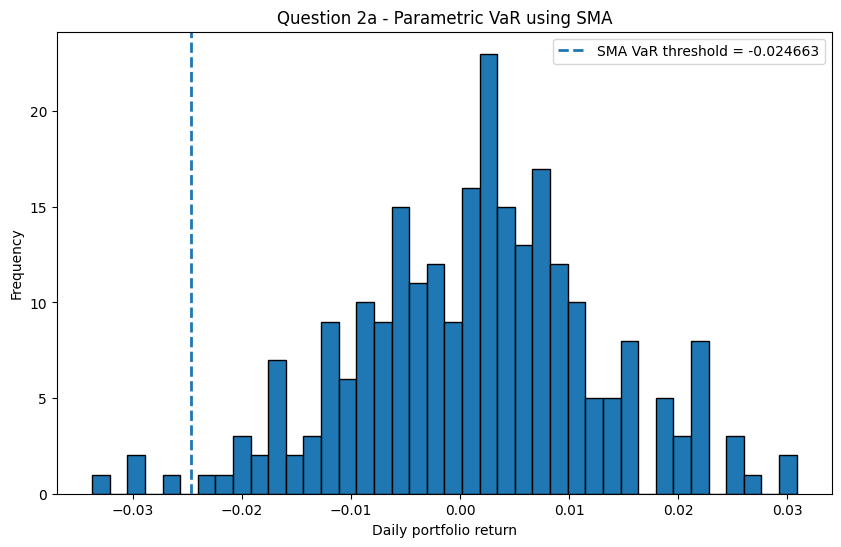

In [22]:
# ============================================================
# QUESTION 2a
# Parametric VaR using SMA
# ============================================================

var_sma_1 = var_parametric(mu_portfolio, sigma_portfolio, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1)

# Return threshold corresponding to VaR in return terms
q_sma_1 = -(var_sma_1 / PORTFOLIO_VALUE_EUR)

print("QUESTION 2a RESULTS")
print("-------------------")
print(f"Mean daily portfolio return = {mu_portfolio:.8f}")
print(f"Daily portfolio volatility (SMA) = {sigma_portfolio:.8f}")
print(f"Daily Parametric VaR (1%) using SMA = {var_sma_1:.2f} EUR")
print(f"VaR threshold in return terms = {q_sma_1:.6f}")

# Plot
plt.figure(figsize=(10, 6))
plt.hist(rp, bins=40, edgecolor="black")
plt.axvline(q_sma_1, linestyle="--", linewidth=2, label=f"SMA VaR threshold = {q_sma_1:.6f}")
plt.title("Question 2a - Parametric VaR using SMA")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Methodology

In the parametric approach, portfolio returns are assumed to follow a normal distribution.

Using the SMA method, the daily portfolio volatility is estimated with the sample standard deviation of historical portfolio returns:

$$
\sigma = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(r_i-\mu)^2}
$$

The daily Value at Risk at the 1% level is then computed as:

$$
VaR_{1\%} = -(\mu + z_{0.01}\sigma)\times V
$$

where:
- $\mu$ is the mean daily portfolio return,
- $\sigma$ is the daily portfolio volatility,
- $z_{0.01} = -2.33$,
- $V$ is the portfolio value.

This approach is called parametric because it relies on the assumption of normality and on the parameters $\mu$ and $\sigma$.

### Comment on the result
The daily parametric VaR (1%) using SMA is **443.93 EUR**.

This means that, under the normality assumption, there is a 1% probability that the portfolio will lose at least **443.93 EUR** in one day.

The SMA method uses equal weights for all past observations, so it produces a stable estimate of volatility, but it may react slowly to recent changes in market conditions. This is why it is useful as a benchmark before comparing it with EWMA, historical simulation, hybrid VaR, and Monte Carlo VaR.

QUESTION 2b RESULTS
-------------------
Chosen lambda = 0.94
EWMA volatility = 0.01393310
Daily Parametric VaR (1%) using EWMA = 556.77 EUR

Sensitivity to lambda:
  lambda = 0.85 → EWMA vol = 0.013815 → VaR = 551.82 EUR
  lambda = 0.90 → EWMA vol = 0.014204 → VaR = 568.13 EUR
  lambda = 0.94 → EWMA vol = 0.013933 → VaR = 556.77 EUR
  lambda = 0.97 → EWMA vol = 0.012846 → VaR = 511.19 EUR


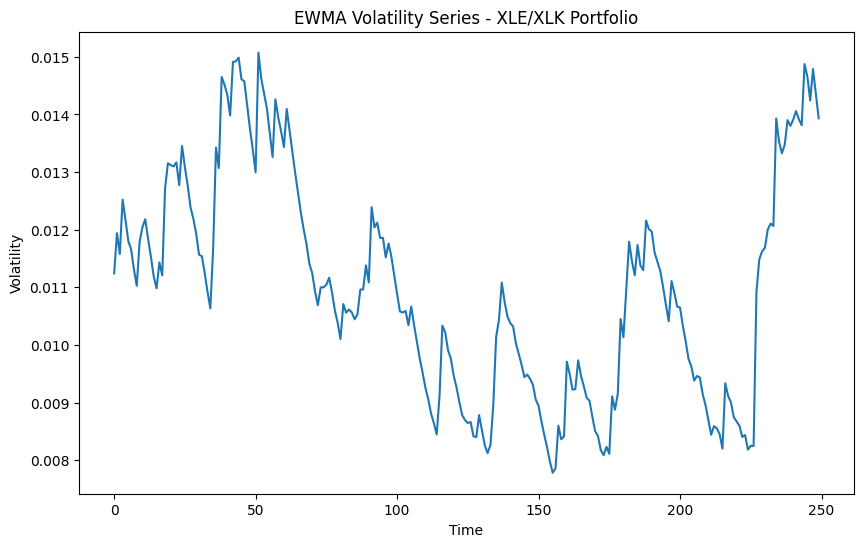

In [23]:
# ============================================================
# QUESTION 2b
# Parametric VaR using EWMA
# ============================================================

var_ewma_1, sigma_ewma, sigma2_series = var_parametric_ewma(
    rp,
    PORTFOLIO_VALUE_EUR,
    ALPHA_VAR_1,
    LAMBDA_EWMA
)

print("QUESTION 2b RESULTS")
print("-------------------")
print(f"Chosen lambda = {LAMBDA_EWMA}")
print(f"EWMA volatility = {sigma_ewma:.8f}")
print(f"Daily Parametric VaR (1%) using EWMA = {var_ewma_1:.2f} EUR")


# Sensitivity to lambda choice
print("\nSensitivity to lambda:")
for lam in [0.85, 0.90, 0.94, 0.97]:
    var_test, sigma_test, _ = var_parametric_ewma(rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1, lam)
    print(f"  lambda = {lam:.2f} → EWMA vol = {sigma_test:.6f} → VaR = {var_test:.2f} EUR")


sigma_series = [math.sqrt(x) for x in sigma2_series]

plt.figure(figsize=(10, 6))
plt.plot(sigma_series)
plt.title(f"EWMA Volatility Series - {TICKER_1}/{TICKER_2} Portfolio")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.show()

### Methodology

In the parametric approach, portfolio returns are assumed to follow a normal distribution.

Unlike the SMA method, the EWMA (Exponentially Weighted Moving Average) approach gives more weight to recent observations when estimating volatility. This allows the model to better capture time-varying volatility.

The EWMA variance is computed recursively as:

$$
\sigma_t^2 = \lambda \sigma_{t-1}^2 + (1-\lambda)r_{t-1}^2
$$

where:
- $\lambda$ is the decay factor,
- recent returns receive higher weight,
- older observations have exponentially decreasing influence.

The daily Value at Risk at the 1% level is then:

$$
VaR_{1\%} = -(\mu + z_{0.01}\sigma_t)\times V
$$

We choose $\lambda = 0.94$. The sensitivity analysis above shows that the EWMA volatility estimates range from 0.012846 ($\lambda = 0.97$) to 0.014204 ($\lambda = 0.90$), which represents relatively small differences — the return series does not exhibit sharp volatility spikes that would require a very reactive model. A high $\lambda$ close to 1 is appropriate here: it smooths out short-term noise while still capturing gradual shifts in volatility. We rule out $\lambda = 0.97$ because it over-smooths and produces a noticeably lower VaR (511.19 EUR), potentially underestimating tail risk. We rule out $\lambda = 0.85$ because it reacts too aggressively to individual observations, which is not justified given the stability of our data over 2021. $\lambda = 0.94$ strikes the right balance for this portfolio.




### Comment on the results

The EWMA VaR (1%) is higher than the SMA VaR (556.77 EUR vs 443.93 EUR).

This difference arises because EWMA assigns greater importance to recent returns. In this dataset, recent volatility appears to be higher than the historical average, which leads to a larger volatility estimate and therefore a higher VaR.

The EWMA volatility plot confirms that volatility is time-varying and increases toward the end of the sample. As a result, the EWMA method reacts more quickly to market conditions than the SMA approach.

Overall, EWMA provides a more responsive and realistic measure of risk, especially in periods of changing volatility.

QUESTION 2c RESULTS
-------------------
Historical daily VaR (1%) = 530.59 EUR
Historical return threshold at 1% = -0.02947735


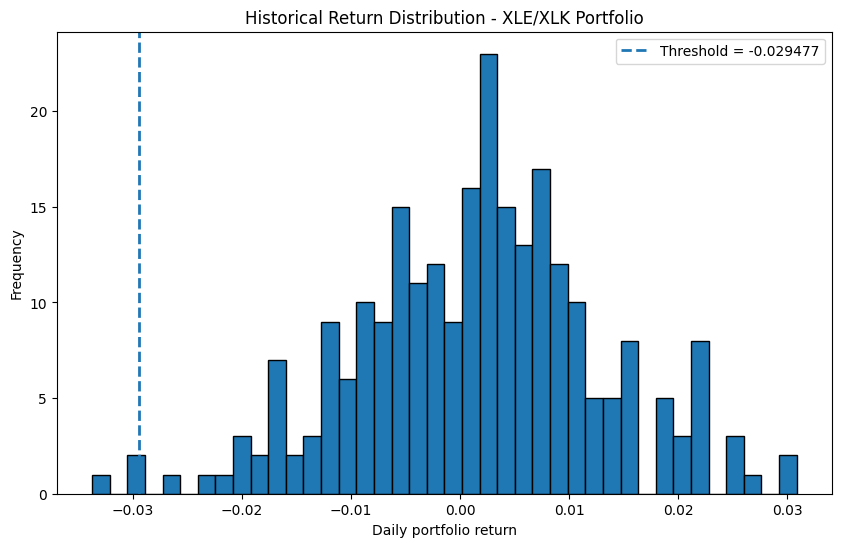

In [24]:
# ============================================================
# QUESTION 2c
# Non-parametric historical VaR
# ============================================================

var_hist_1, q_hist_1 = var_historical(rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1)

print("QUESTION 2c RESULTS")
print("-------------------")
print(f"Historical daily VaR (1%) = {var_hist_1:.2f} EUR")
print(f"Historical return threshold at 1% = {q_hist_1:.8f}")

plt.figure(figsize=(10, 6))
plt.hist(rp, bins=40, edgecolor="black")
plt.axvline(q_hist_1, linestyle="--", linewidth=2, label=f"Threshold = {q_hist_1:.6f}")
plt.title(f"Historical Return Distribution - {TICKER_1}/{TICKER_2} Portfolio")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

QUESTION 2d RESULTS
-------------------
Chosen lambda = 0.94
Hybrid daily VaR (1%) = 545.57 EUR
Hybrid return threshold at 1% = -0.03030932


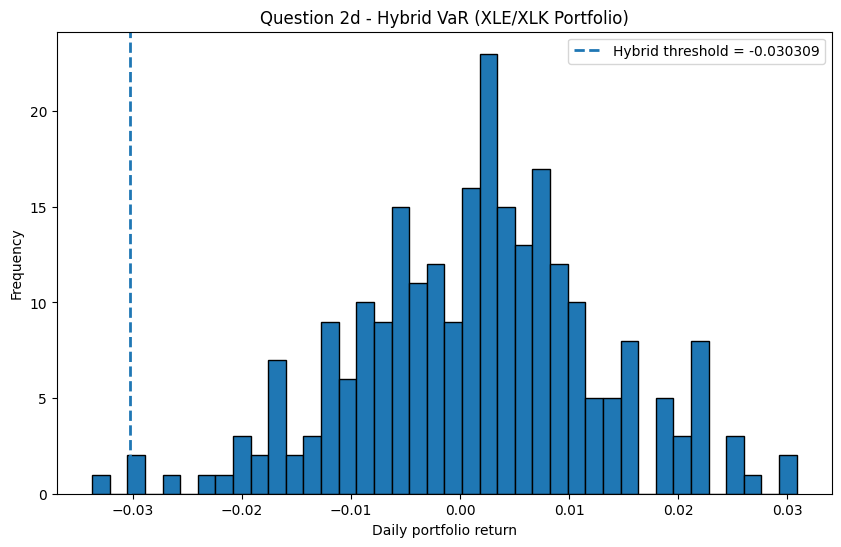

In [25]:
# ============================================================
# QUESTION 2d
# Hybrid VaR
# ============================================================

var_hyb_1, q_hyb_1 = var_hybrid(rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1, LAMBDA_HYBRID)

print("QUESTION 2d RESULTS")
print("-------------------")
print(f"Chosen lambda = {LAMBDA_HYBRID}")
print(f"Hybrid daily VaR (1%) = {var_hyb_1:.2f} EUR")
print(f"Hybrid return threshold at 1% = {q_hyb_1:.8f}")

plt.figure(figsize=(10, 6))
plt.hist(rp, bins=40, edgecolor="black")
plt.axvline(q_hyb_1, linestyle="--", linewidth=2, label=f"Hybrid threshold = {q_hyb_1:.6f}")
plt.title(f"Question 2d - Hybrid VaR ({TICKER_1}/{TICKER_2} Portfolio)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Methodology

The hybrid approach combines the historical simulation method with exponentially weighted observations.

Unlike the parametric approaches, it does not assume that returns follow a normal distribution. Instead, it uses the empirical distribution of historical returns, but assigns higher weights to more recent observations.

The weights are defined as:

$$
w_i = \frac{(1-\lambda)}{1-\lambda^N} \cdot \lambda^{N-i}
$$

where:
- $\lambda$ is the decay factor,
- $N$ is the number of observations,
- more recent returns receive larger weights.

The procedure is:
1. assign exponentially decreasing weights to past returns,
2. sort the returns from worst to best,
3. compute the cumulative weights,
4. identify the return where the cumulative weight reaches 1%,
5. convert this return into EUR.

We use $\lambda = 0.94$, consistent with the EWMA approach. Our data over 2021 exhibits moderate and stable volatility that does not require a highly reactive weighting scheme, making this value appropriate.

### Comment on the results

The hybrid daily VaR (1%) is **545.57 EUR**, with a return threshold of **-0.030309**.

This estimate lies between the historical VaR (530.60 EUR) and the EWMA VaR (556.77 EUR), which is expected — the hybrid approach preserves the empirical distribution while giving more importance to recent observations, making it more responsive than pure historical simulation but less aggressive than EWMA.

The result confirms that recent returns in 2021 carried slightly more weight toward the tail, pushing the threshold slightly beyond what the unweighted historical approach would give.

QUESTION 2e RESULTS
-------------------
Number of simulations = 20000
Monte Carlo daily VaR (1%) = 441.66 EUR


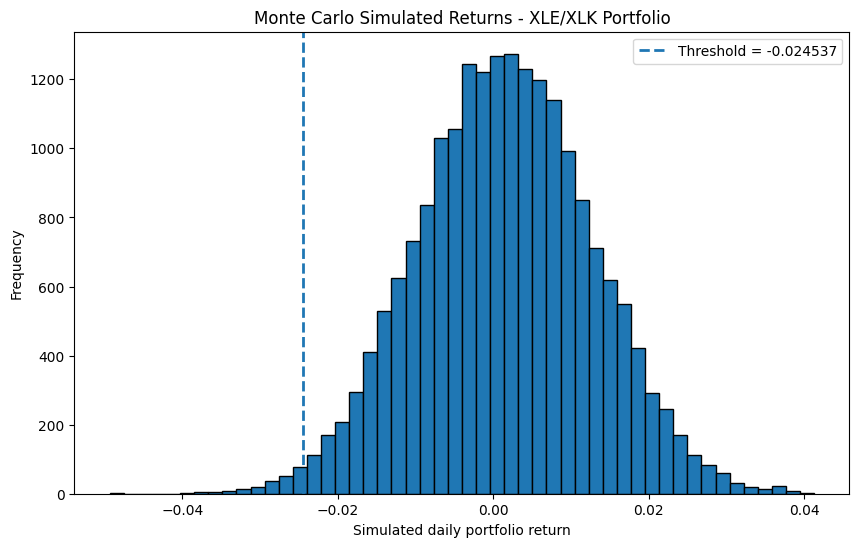

In [26]:
# ============================================================
# QUESTION 2e
# Monte Carlo VaR
# ============================================================

var_mc_1, sim_returns_mc, q_mc_1 = monte_carlo_var_parametric(
    mu_portfolio,
    sigma_portfolio,
    PORTFOLIO_VALUE_EUR,
    ALPHA_VAR_1,
    N_MONTE_CARLO
)

print("QUESTION 2e RESULTS")
print("-------------------")
print(f"Number of simulations = {N_MONTE_CARLO}")
print(f"Monte Carlo daily VaR (1%) = {var_mc_1:.2f} EUR")

plt.figure(figsize=(10, 6))
plt.hist(sim_returns_mc, bins=50, edgecolor="black")
plt.axvline(q_mc_1, linestyle="--", linewidth=2, label=f"Threshold = {q_mc_1:.6f}")
plt.title(f"Monte Carlo Simulated Returns - {TICKER_1}/{TICKER_2} Portfolio")
plt.xlabel("Simulated daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()




### Methodology

The Monte Carlo approach estimates Value at Risk by simulating a large number of possible future portfolio returns.

In this case, we assume that portfolio returns follow a normal distribution with mean $\mu$ and volatility $\sigma$, estimated from historical data.

The procedure is:
1. estimate the mean return $\mu$ and volatility $\sigma$ of the portfolio,
2. generate a large number of random returns using:
   
   $$
   R = \mu + \sigma Z
   $$

   where $Z \sim N(0,1)$,
3. repeat this process for many simulations (here 20,000),
4. sort the simulated returns from worst to best,
5. identify the 1st percentile,
6. convert this return into EUR.

The daily Value at Risk is then:

$$
VaR_{1\%} = -q_{1\%} \times V
$$

where $q_{1\%}$ is the 1st percentile of the simulated return distribution.



### Comment on the results

The Monte Carlo VaR (1%) is **441.66 EUR**, which is very close to the parametric VaR using SMA and lower than the EWMA, historical, and hybrid VaR estimates.

This is expected because the simulation is based on the assumption of normally distributed returns using the same mean and volatility as the parametric approach. As a result, it produces similar results to the SMA VaR.

However, unlike the historical method, Monte Carlo simulation does not rely directly on past observations. Instead, it generates synthetic scenarios, which allows for greater flexibility and scalability.

The histogram of simulated returns shows a smooth, symmetric distribution, consistent with the normality assumption. This explains why extreme losses are less pronounced compared to the historical or hybrid approaches.

Overall, the Monte Carlo VaR provides a flexible and intuitive way to estimate risk, but its accuracy depends heavily on the assumptions made about the return distribution.

COMPARISON OF VaR APPROACHES (1%)
----------------------------------
SMA Parametric VaR      = 443.93 EUR
EWMA Parametric VaR     = 556.77 EUR
Historical VaR          = 530.59 EUR
Hybrid VaR              = 545.57 EUR
Monte Carlo VaR         = 441.66 EUR


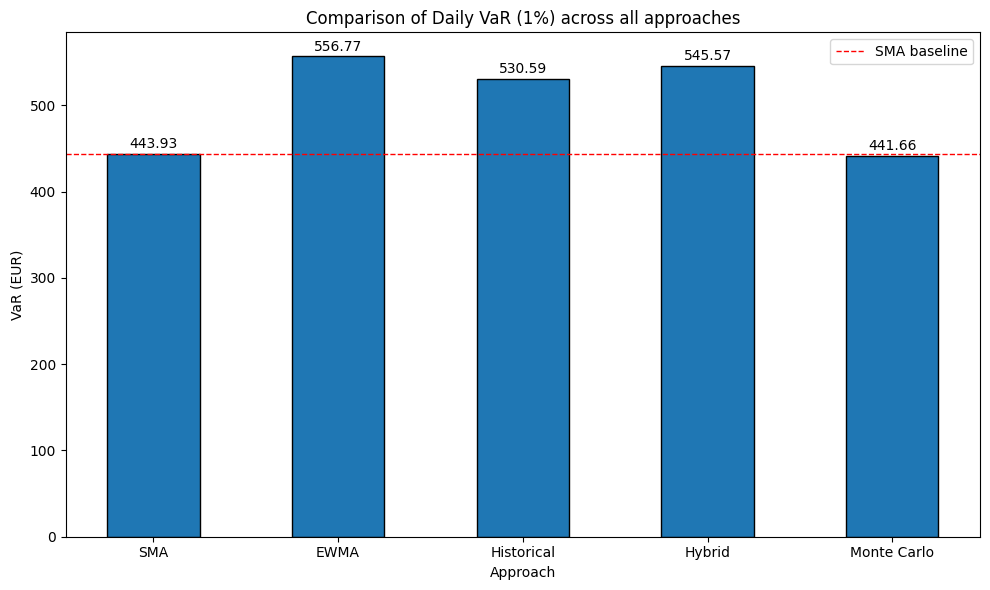

In [27]:
# ============================================================
# QUESTION 2f
# Comparison of VaR approaches
# ============================================================

print("COMPARISON OF VaR APPROACHES (1%)")
print("----------------------------------")
print(f"SMA Parametric VaR      = {var_sma_1:.2f} EUR")
print(f"EWMA Parametric VaR     = {var_ewma_1:.2f} EUR")
print(f"Historical VaR          = {var_hist_1:.2f} EUR")
print(f"Hybrid VaR              = {var_hyb_1:.2f} EUR")
print(f"Monte Carlo VaR         = {var_mc_1:.2f} EUR")

# Bar chart comparison
approaches = ["SMA", "EWMA", "Historical", "Hybrid", "Monte Carlo"]
var_values = [var_sma_1, var_ewma_1, var_hist_1, var_hyb_1, var_mc_1]

plt.figure(figsize=(10, 6))
bars = plt.bar(approaches, var_values, edgecolor="black", width=0.5)
plt.axhline(y=var_sma_1, linestyle="--", linewidth=1, color="red", label="SMA baseline")
for bar, val in zip(bars, var_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
             f"{val:.2f}", ha="center", va="bottom", fontsize=10)
plt.title("Comparison of Daily VaR (1%) across all approaches")
plt.xlabel("Approach")
plt.ylabel("VaR (EUR)")
plt.legend()
plt.tight_layout()
plt.show()

## Question 2f — Comparison of the VaR approaches

The different Value at Risk estimates show noticeable differences depending on the methodology used.

The **parametric VaR using SMA (443.93 EUR)** is the lowest estimate. This is because it assumes constant volatility and normally distributed returns, which tends to underestimate extreme losses.

The **EWMA VaR (556.7- EUR)** is significantly higher. This reflects the fact that EWMA gives more weight to recent observations, capturing higher recent volatility and therefore producing a more conservative risk estimate.

The **historical VaR (530.60 EUR)** is also higher than the SMA VaR. Since it is based on actual past returns, it captures extreme negative returns that may not be well represented under the normality assumption.

The **hybrid VaR (545.57 EUR)** lies between the historical and EWMA estimates. It combines the advantages of both approaches by preserving the empirical distribution while giving more importance to recent data. This makes it more responsive to current market conditions.

Finally, the **Monte Carlo VaR (441.66 EUR)** is very close to the SMA VaR. This is expected because the simulation assumes normally distributed returns using the same mean and volatility as the parametric approach.

Overall:
- Parametric methods tend to **underestimate risk** when returns are not perfectly normal,
- Historical and hybrid methods provide **more realistic estimates of extreme losses**,
- EWMA and hybrid approaches are **more responsive to recent market conditions**.

Therefore, the choice of method has a significant impact on the estimated level of risk, and more advanced approaches generally produce more conservative and realistic VaR estimates.

QUESTION 3 RESULTS
------------------
Daily VaR (1%)   = 443.93 EUR
Weekly VaR (1%)  = 992.66 EUR
Monthly VaR (1%) = 2034.36 EUR
Annual VaR (1%)  = 7047.22 EUR

Daily VaR (10%)   = 231.45 EUR
Weekly VaR (10%)  = 517.53 EUR
Monthly VaR (10%) = 1060.61 EUR
Annual VaR (10%)  = 3674.08 EUR


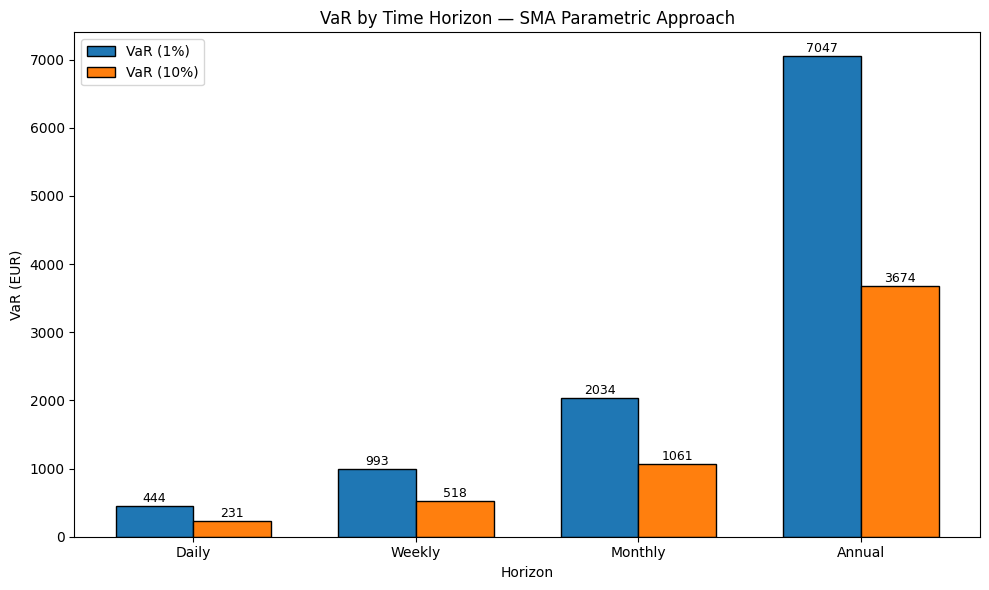

In [34]:
# ============================================================
# QUESTION 3
# Weekly, monthly, annual VaR and VaR(10%)
# ============================================================

var_daily_1 = var_sma_1
var_weekly_1 = scale_var_sqrt_time(var_daily_1, 5)
var_monthly_1 = scale_var_sqrt_time(var_daily_1, 21)
var_annual_1 = scale_var_sqrt_time(var_daily_1, 252)

var_daily_10 = var_parametric(mu_portfolio, sigma_portfolio, PORTFOLIO_VALUE_EUR, ALPHA_VAR_10)
var_weekly_10 = scale_var_sqrt_time(var_daily_10, 5)
var_monthly_10 = scale_var_sqrt_time(var_daily_10, 21)
var_annual_10 = scale_var_sqrt_time(var_daily_10, 252)

print("QUESTION 3 RESULTS")
print("------------------")
print(f"Daily VaR (1%)   = {var_daily_1:.2f} EUR")
print(f"Weekly VaR (1%)  = {var_weekly_1:.2f} EUR")
print(f"Monthly VaR (1%) = {var_monthly_1:.2f} EUR")
print(f"Annual VaR (1%)  = {var_annual_1:.2f} EUR")
print()
print(f"Daily VaR (10%)   = {var_daily_10:.2f} EUR")
print(f"Weekly VaR (10%)  = {var_weekly_10:.2f} EUR")
print(f"Monthly VaR (10%) = {var_monthly_10:.2f} EUR")
print(f"Annual VaR (10%)  = {var_annual_10:.2f} EUR")

# Bar chart VaR by horizon
horizons = ["Daily", "Weekly", "Monthly", "Annual"]
var_1pct  = [var_daily_1, var_weekly_1, var_monthly_1, var_annual_1]
var_10pct = [var_daily_10, var_weekly_10, var_monthly_10, var_annual_10]

x = range(len(horizons))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar([i - width/2 for i in x], var_1pct, width, label="VaR (1%)", edgecolor="black")
bars2 = plt.bar([i + width/2 for i in x], var_10pct, width, label="VaR (10%)", edgecolor="black")
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)
plt.title("VaR by Time Horizon — SMA Parametric Approach")
plt.xlabel("Horizon")
plt.ylabel("VaR (EUR)")
plt.xticks(x, horizons)
plt.legend()
plt.tight_layout()
plt.show()

### Methodology

**Scaling VaR over time — the square root of time rule**

Under the assumption that daily returns are independent and identically distributed, the VaR scales with the square root of the number of trading days:

$$
VaR_T = VaR_{daily} \times \sqrt{T}
$$

where $T$ is the number of trading days:
- $T = 5$ for weekly VaR,
- $T = 21$ for monthly VaR,
- $T = 252$ for annual VaR.

**Converting VaR(1%) to VaR(10%)**

To convert between confidence levels, we use the ratio of the corresponding normal quantiles:

$$
VaR_{10\%} = VaR_{1\%} \times \frac{z_{10\%}}{z_{1\%}} = VaR_{1\%} \times \frac{1.282}{2.326}
$$

### Results summary

| Horizon  | VaR (1%)    | VaR (10%)   |
|----------|------------|------------|
| Daily    | 443.93 EUR | 231.45 EUR |
| Weekly   | 992.66 EUR | 517.53 EUR |
| Monthly  | 2034.36 EUR| 1060.61 EUR|
| Annual   | 7047.22 EUR| 3674.08 EUR|

### Comment on the results

As expected, VaR increases with the time horizon — the longer the holding period, the greater the potential loss. The annual VaR (1%) of 7047.22 EUR represents approximately **39% of the portfolio value** (18,000 EUR), which illustrates the significant risk accumulation over a full year.

The VaR(10%) is consistently lower than VaR(1%) across all horizons, since a 10% confidence level corresponds to a less extreme tail event. The ratio between the two is constant at $\frac{1.282}{2.326} \approx 0.551$, which is a direct consequence of the normality assumption.

QUESTION 4 RESULTS
------------------
Stressed period = 2020-02-01 to 2020-12-31
Historical VaR (1%) in normal period = 530.59 EUR
Historical Stressed VaR (1%)         = 1927.84 EUR
Difference                           = 1397.25 EUR


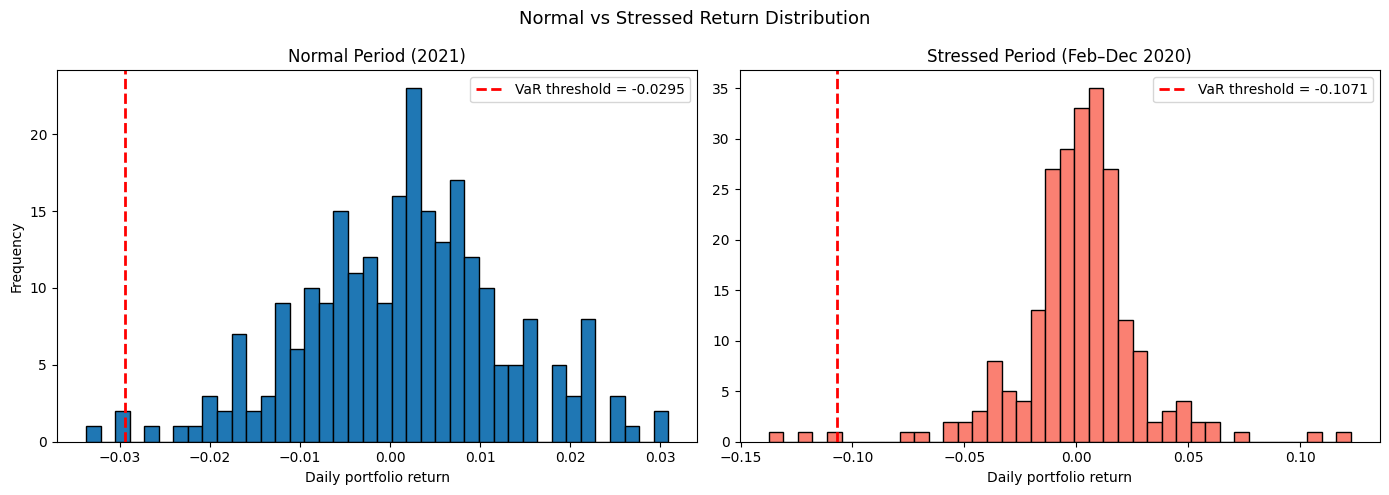

In [35]:
# ============================================================
# QUESTION 4
# Stressed historical VaR
# ============================================================

stress_dates1, stress_prices1 = download_adjusted_close(TICKER_1, STRESS_START, STRESS_END)
stress_dates2, stress_prices2 = download_adjusted_close(TICKER_2, STRESS_START, STRESS_END)

stress_dates_common, stress_p1, stress_p2 = align_two_series(
    stress_dates1, stress_prices1, stress_dates2, stress_prices2
)

stress_r1 = simple_returns(stress_p1)
stress_r2 = simple_returns(stress_p2)
stress_rp = portfolio_returns_two_assets(stress_r1, stress_r2, W1, W2)

stressed_var_hist_1, _ = var_historical(stress_rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1)

print("QUESTION 4 RESULTS")
print("------------------")
print(f"Stressed period = {STRESS_START} to {STRESS_END}")
print(f"Historical VaR (1%) in normal period = {var_hist_1:.2f} EUR")
print(f"Historical Stressed VaR (1%)         = {stressed_var_hist_1:.2f} EUR")
print(f"Difference                           = {stressed_var_hist_1 - var_hist_1:.2f} EUR")

# Side by side comparison normal vs stressed distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

_, q_normal = var_historical(rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1)
_, q_stress = var_historical(stress_rp, PORTFOLIO_VALUE_EUR, ALPHA_VAR_1)

ax1.hist(rp, bins=40, edgecolor="black")
ax1.axvline(q_normal, linestyle="--", linewidth=2, color="red",
            label=f"VaR threshold = {q_normal:.4f}")
ax1.set_title("Normal Period (2021)")
ax1.set_xlabel("Daily portfolio return")
ax1.set_ylabel("Frequency")
ax1.legend()

ax2.hist(stress_rp, bins=40, edgecolor="black", color="salmon")
ax2.axvline(q_stress, linestyle="--", linewidth=2, color="red",
            label=f"VaR threshold = {q_stress:.4f}")
ax2.set_title("Stressed Period (Feb–Dec 2020)")
ax2.set_xlabel("Daily portfolio return")
ax2.legend()

plt.suptitle("Normal vs Stressed Return Distribution", fontsize=13)
plt.tight_layout()
plt.show()



## Interpretation

The stressed historical VaR is significantly higher than the VaR computed over the normal period.

In the normal period, the 1% historical VaR is **530.60 EUR**, whereas during the stressed period it increases sharply to **1927.84 EUR**. This represents an increase of **1397.24 EUR**, which is almost four times higher.

This difference can be explained by the extreme market conditions during the stressed period (COVID-19 crisis in 2020). During such periods, financial markets experience:
- higher volatility,
- larger negative returns,
- more frequent extreme losses.

Since the historical VaR is based directly on observed returns, it fully captures these extreme movements, leading to a much larger risk estimate.

This result highlights an important limitation of using only normal-period data: it can significantly **underestimate risk** in times of crisis.

The chart confirms this visually: the stressed distribution (right panel) is much wider 
and more left-skewed than the normal period distribution (left panel). The VaR threshold 
shifts from **-0.0295** in the normal period to **-0.1071** during the crisis, meaning 
the portfolio could lose more than **10% of its value in a single day** at the 1% level 
during the COVID-19 shock. This is a dramatic shift that no normal-period model would 
have anticipated.


Overall, the stressed VaR provides a more conservative and realistic measure of potential losses under adverse market conditions, and it is particularly useful for risk management and regulatory purposes.

QUESTION 5 RESULTS
------------------
Underlying asset for the option = XLK
Current underlying price S0 = 84.5498
Strike price K = 84.5498
Annualized volatility = 0.192831
Delta = 0.534948
Gamma = 0.084439
Taylor delta-gamma VaR (1%) = 1.690877 EUR per option


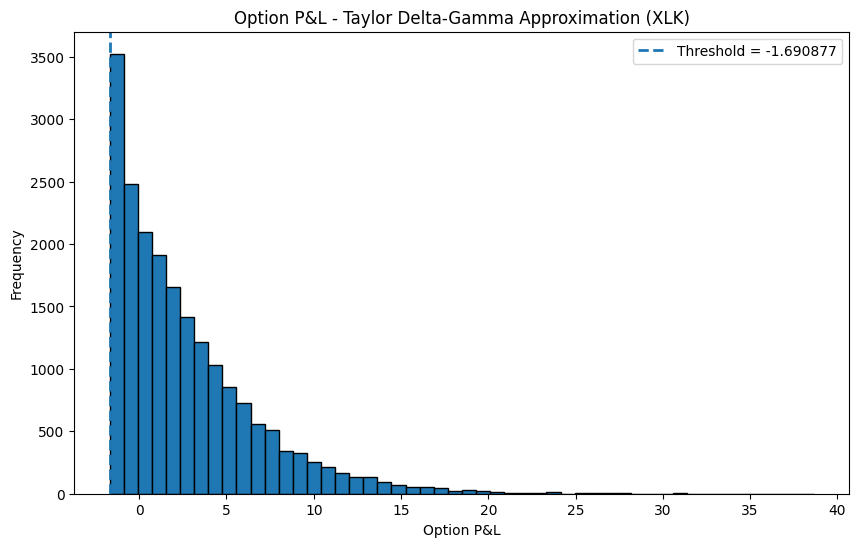

In [30]:
# ============================================================
# QUESTION 5
# Taylor series VaR for the call option
# ============================================================

if OPTION_UNDERLYING == TICKER_1:
    underlying_prices = p1
    underlying_returns = r1
else:
    underlying_prices = p2
    underlying_returns = r2

S0_option = underlying_prices[-1]
sigma_underlying = std_manual_sample(underlying_returns) * math.sqrt(252.0)
mu_underlying = mean_manual(underlying_returns) * 252.0

if OPTION_STRIKE_STYLE == "ATM":
    K_option = S0_option
else:
    K_option = OPTION_STRIKE_CUSTOM

taylor_var_1, taylor_pnl, delta_option, gamma_option = var_taylor_delta_gamma(
    S0=S0_option,
    K=K_option,
    r=RISK_FREE_RATE,
    sigma=sigma_underlying,
    T=OPTION_MATURITY_YEARS,
    mu_underlying=mu_underlying,
    n_paths=N_MONTE_CARLO,
    alpha=ALPHA_VAR_1
)

print("QUESTION 5 RESULTS")
print("------------------")
print(f"Underlying asset for the option = {OPTION_UNDERLYING}")
print(f"Current underlying price S0 = {S0_option:.4f}")
print(f"Strike price K = {K_option:.4f}")
print(f"Annualized volatility = {sigma_underlying:.6f}")
print(f"Delta = {delta_option:.6f}")
print(f"Gamma = {gamma_option:.6f}")
print(f"Taylor delta-gamma VaR (1%) = {taylor_var_1:.6f} EUR per option")

plt.figure(figsize=(10, 6))
plt.hist(taylor_pnl, bins=50, edgecolor="black")
plt.axvline(-taylor_var_1, linestyle="--", linewidth=2, label=f"Threshold = {-taylor_var_1:.6f}")
plt.title(f"Option P&L - Taylor Delta-Gamma Approximation ({OPTION_UNDERLYING})")
plt.xlabel("Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

### Comment on the Results

The estimated VaR (1%) is approximately 1.69 EUR per option. The P&L distribution is asymmetric, with limited losses and larger potential gains, which reflects the non-linear payoff of a call option. 

The Delta-Gamma approximation captures this non-linearity through the Gamma term, providing a more accurate risk estimate than a simple linear approximation.

QUESTION 6 RESULTS
------------------
Parametric VaR (5%) = 306.32 EUR
Parametric ES  (5%) = 386.32 EUR
Historical VaR (5%) = 298.93 EUR
Historical ES  (5%) = 406.15 EUR


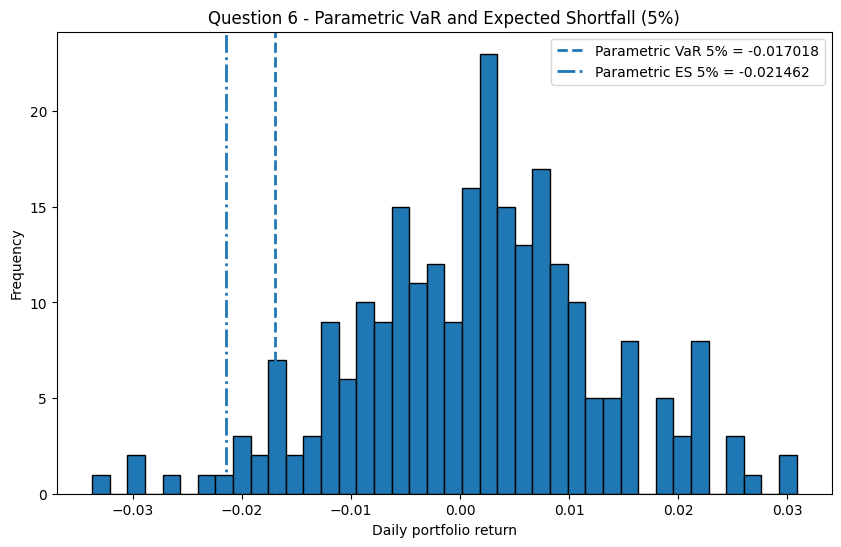

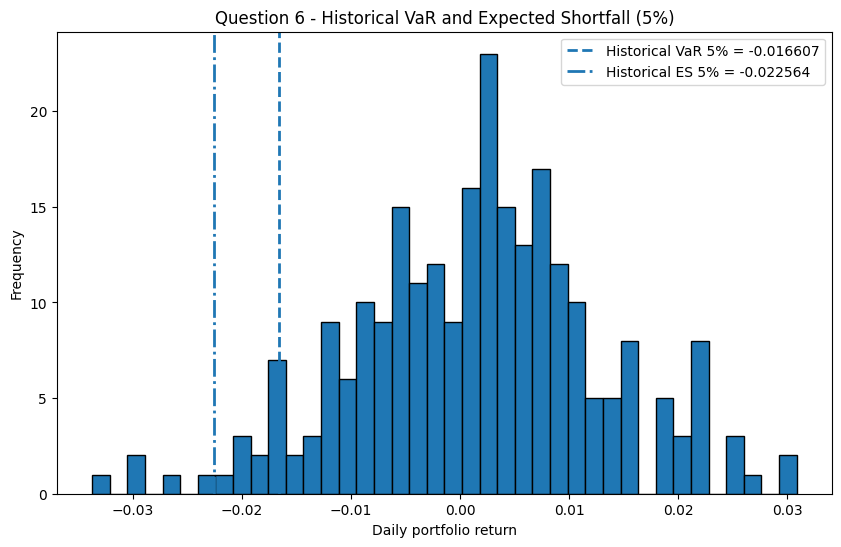

In [31]:
# ============================================================
# QUESTION 6
# Expected Shortfall for parametric and non-parametric approaches
# ============================================================

es_param_5 = es_parametric_normal(
    mu_portfolio,
    sigma_portfolio,
    PORTFOLIO_VALUE_EUR,
    ALPHA_ES_5
)

es_hist_5, q_es_hist_5 = es_historical(
    rp,
    PORTFOLIO_VALUE_EUR,
    ALPHA_ES_5
)

var_param_5 = var_parametric(
    mu_portfolio,
    sigma_portfolio,
    PORTFOLIO_VALUE_EUR,
    ALPHA_VAR_5
)

var_hist_5, q_hist_5 = var_historical(
    rp,
    PORTFOLIO_VALUE_EUR,
    ALPHA_VAR_5
)

# Convert EUR risk measures to return thresholds for plotting
q_param_5 = -(var_param_5 / PORTFOLIO_VALUE_EUR)

# Parametric ES threshold in return terms:
# ES = (-mu + sigma*phi(z)/alpha)*V
# so tail mean return = -ES / V
q_param_es_return = -(es_param_5 / PORTFOLIO_VALUE_EUR)

q_hist_es_return = -(es_hist_5 / PORTFOLIO_VALUE_EUR)

print("QUESTION 6 RESULTS")
print("------------------")
print(f"Parametric VaR (5%) = {var_param_5:.2f} EUR")
print(f"Parametric ES  (5%) = {es_param_5:.2f} EUR")
print(f"Historical VaR (5%) = {var_hist_5:.2f} EUR")
print(f"Historical ES  (5%) = {es_hist_5:.2f} EUR")

# -------------------------
# Plot 1: Parametric VaR and ES
# -------------------------
plt.figure(figsize=(10, 6))
plt.hist(rp, bins=40, edgecolor="black")
plt.axvline(q_param_5, linestyle="--", linewidth=2, label=f"Parametric VaR 5% = {q_param_5:.6f}")
plt.axvline(q_param_es_return, linestyle="-.", linewidth=2, label=f"Parametric ES 5% = {q_param_es_return:.6f}")
plt.title("Question 6 - Parametric VaR and Expected Shortfall (5%)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# -------------------------
# Plot 2: Historical VaR and ES
# -------------------------
plt.figure(figsize=(10, 6))
plt.hist(rp, bins=40, edgecolor="black")
plt.axvline(q_hist_5, linestyle="--", linewidth=2, label=f"Historical VaR 5% = {q_hist_5:.6f}")
plt.axvline(q_hist_es_return, linestyle="-.", linewidth=2, label=f"Historical ES 5% = {q_hist_es_return:.6f}")
plt.title("Question 6 - Historical VaR and Expected Shortfall (5%)")
plt.xlabel("Daily portfolio return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Methodology

Expected Shortfall (ES) measures the **average loss beyond the VaR threshold**, and therefore provides a more complete view of tail risk.

### Parametric approach

In the parametric framework, portfolio returns are assumed to follow a normal distribution:

$$
R \sim \mathcal{N}(\mu, \sigma^2)
$$

The Expected Shortfall at the 5% level is computed using:

$$
ES_{5\%} = \left( -\mu + \frac{\sigma \cdot \phi(z_{5\%})}{0.05} \right) \cdot V
$$

This approach depends only on the estimated mean and volatility, and assumes symmetric, normally distributed returns.

#### Historical (non-parametric) approach

The historical ES is computed directly from observed data:

1. Returns are sorted from worst to best  
2. The 5% VaR threshold is identified  
3. ES is calculated as the **average of all returns below this threshold**

This approach is fully data-driven and captures the empirical distribution of returns, including extreme events.



### Comment on the Results

The results show that:

- Parametric VaR (5%) = **306.32 EUR**  
- Parametric ES (5%)  = **386.32 EUR**  
- Historical VaR (5%) = **298.93 EUR**  
- Historical ES (5%)  = **406.15 EUR**

As expected, **ES is higher than VaR** in both approaches because it reflects the **average severity of losses in the tail**, rather than just the cutoff point.

The historical ES is higher than the parametric ES, indicating that the empirical distribution exhibits **heavier tails** than the normal distribution. This suggests that extreme losses occur more frequently than predicted under the normality assumption.



### Comparison of the Two Approaches

- The **parametric approach** produces slightly higher VaR but lower ES. This reflects the limitations of the normal distribution, which tends to underestimate extreme tail losses.

- The **historical approach** captures more severe losses in the tail, leading to a higher ES. This makes it more sensitive to actual market shocks present in the data.

- The difference between the two ES values highlights the importance of accounting for **non-normality and fat tails** in financial returns.


Expected Shortfall provides a more robust measure of risk than VaR by incorporating the magnitude of extreme losses. The comparison shows that relying solely on parametric assumptions may underestimate tail risk, while the historical approach offers a more realistic assessment in the presence of extreme market movements.

QUESTION 7 RESULTS
------------------
Current option price C0 = 2.018299
Full Repricing VaR (1%) = 1.038869 EUR per option

Taylor Delta-Gamma VaR (1%) = 1.690877 EUR
Full Repricing VaR (1%)     = 1.038869 EUR


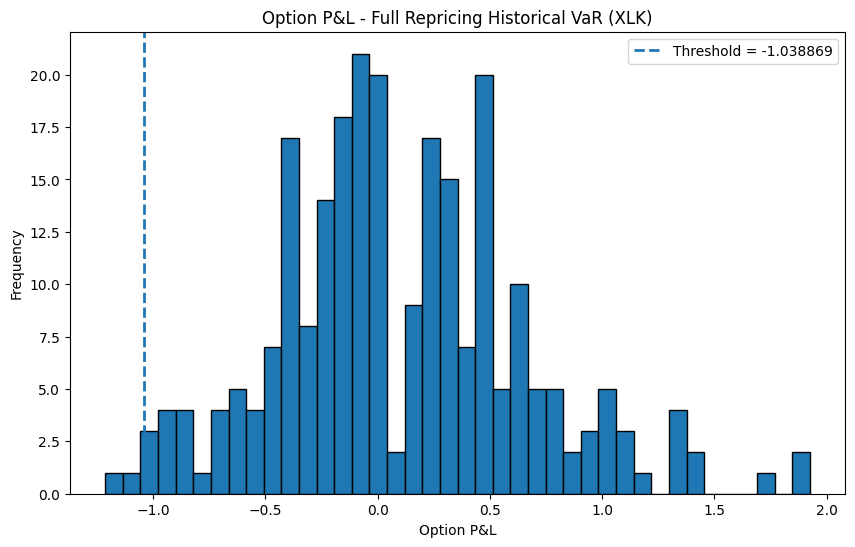

In [32]:
# ============================================================
# QUESTION 7
# Full Repricing VaR for the call option
# ============================================================

full_repricing_var_1, full_pnl, C0 = full_repricing_var_historical(
    price_series_underlying=underlying_prices,
    sigma=sigma_underlying,
    r=RISK_FREE_RATE,
    T=OPTION_MATURITY_YEARS,
    K=K_option,
    alpha=ALPHA_VAR_1
)

print("QUESTION 7 RESULTS")
print("------------------")
print(f"Current option price C0 = {C0:.6f}")
print(f"Full Repricing VaR (1%) = {full_repricing_var_1:.6f} EUR per option")
print()
print(f"Taylor Delta-Gamma VaR (1%) = {taylor_var_1:.6f} EUR")
print(f"Full Repricing VaR (1%)     = {full_repricing_var_1:.6f} EUR")

plt.figure(figsize=(10, 6))
plt.hist(full_pnl, bins=40, edgecolor="black")
plt.axvline(-full_repricing_var_1, linestyle="--", linewidth=2, label=f"Threshold = {-full_repricing_var_1:.6f}")
plt.title(f"Option P&L - Full Repricing Historical VaR ({OPTION_UNDERLYING})")
plt.xlabel("Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [33]:
# ============================================================
# QUESTION 7 - COMPARISON
# Full Repricing VaR vs Taylor VaR vs Parametric VaR (SMA)
# ============================================================

print("QUESTION 7 COMPARISON")
print("---------------------")
print(f"Parametric VaR (SMA) from Q2a       = {var_sma_1:.2f} EUR")
print(f"Taylor Delta-Gamma VaR from Q5      = {taylor_var_1:.6f} EUR per option")
print(f"Full Repricing VaR from Q7          = {full_repricing_var_1:.6f} EUR per option")

QUESTION 7 COMPARISON
---------------------
Parametric VaR (SMA) from Q2a       = 443.93 EUR
Taylor Delta-Gamma VaR from Q5      = 1.690877 EUR per option
Full Repricing VaR from Q7          = 1.038869 EUR per option


## Comparison of Full Repricing VaR, Taylor VaR and Parametric VaR

The Full Repricing VaR (1%) can be compared with both the Taylor series (delta-gamma) VaR from Question 5 and the parametric VaR using SMA from Question 2a.

The **Taylor delta-gamma VaR** is an approximation of the option price change based on the first and second derivatives of the option price. It improves on a purely linear approximation because it includes curvature through the gamma term, but it is still only a local approximation.

The **Full Repricing VaR** is obtained by fully revaluing the option under each historical scenario using the Black-Scholes formula. This means that the option price is recalculated exactly for each shocked underlying price, instead of being approximated.

The **parametric VaR (SMA)** from Question 2a is based on the normality assumption and is designed for the portfolio return distribution. It does not fully capture the non-linear payoff structure of an option.

### Comment on the differences

The Taylor delta-gamma VaR is higher than the Full Repricing VaR in this case. This suggests that the Taylor approximation slightly overestimates the loss in the tail for the simulated option P&L distribution.

The Full Repricing VaR is more accurate because it uses the complete option pricing formula for every scenario. It therefore captures the true non-linear relationship between the option value and the underlying asset price.

By contrast, the parametric VaR approach assumes linearity and normality. This may be reasonable for standard portfolios of stocks or ETFs, but it is not sufficient for options, whose payoffs are asymmetric and non-linear.

Overall, Full Repricing captures non-linearities that the parametric approach misses because it revalues the option exactly under each shocked market scenario instead of approximating the change with only summary parameters such as mean and volatility.